# Time Series Analysis : Components and Forecasting ARIMA

![](https://bizznotes.com/wp-content/uploads/2022/06/7807104_1578230927_time_analysis_tittle-banner-1.jpg)

A Time Series is a set of observations that are collected after regular intervals of time. It represents of time-based orders. This would be Years, Months, Weeks, Days, Hours, Minutes, and Seconds.

Time-Series Forecasting is the process of using a statistical model to predict future values of a time-series based on past results. In fact that A time series analysis encompasses statistical methods for analyzing time series data. These methods enable us to extract meaningful statistics, patterns and other characteristics of the data.

### **Time Series Components**

* Stationarity
* Trend
* Seasonality
* Cyclical variations
* Irregular variations

# Importing Libraries

In [1]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
%matplotlib inline


# Loading Dataset

In [5]:
df = pd.read_csv("energydata_complete.csv")
df = df[["date", "Appliances"]]
df.head()

,date,Appliances
0,14/02/2016 0:00,50
1,14/02/2016 0:10,50
2,14/02/2016 0:20,60
3,14/02/2016 0:30,40
4,14/02/2016 0:40,60


# Rolling Statistics

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

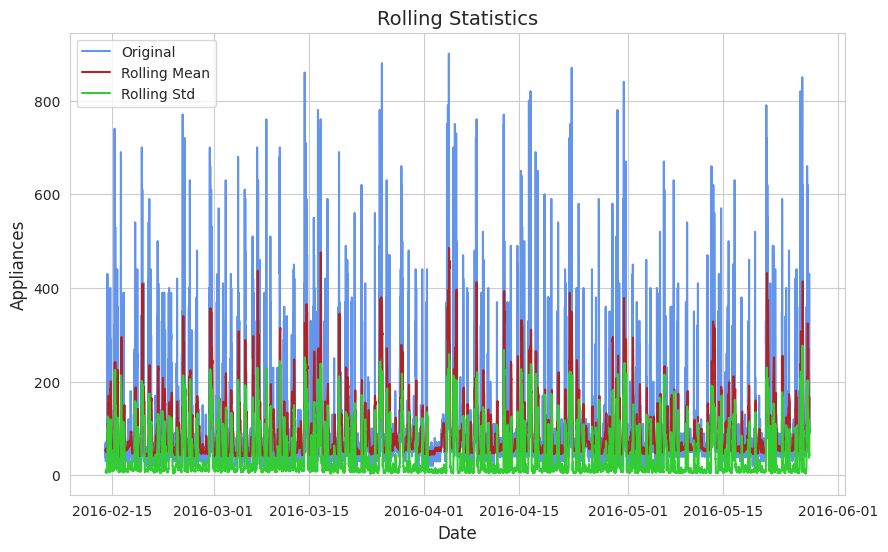

In [18]:
rolling_mean = df.rolling(window=900//60).mean()
rolling_std = df.rolling(window=900//60).std()
plt.figure(figsize = (10,6))
plt.plot(df, color='cornflowerblue', label='Original')
plt.plot(rolling_mean, color='firebrick', label='Rolling Mean')
plt.plot(rolling_std, color='limegreen', label='Rolling Std')
plt.xlabel('Date', size = 12)
plt.ylabel('Appliances', size = 12)
plt.legend(loc = 'upper left')
plt.title('Rolling Statistics', size = 14)
plt.show()

# Checking Stationary

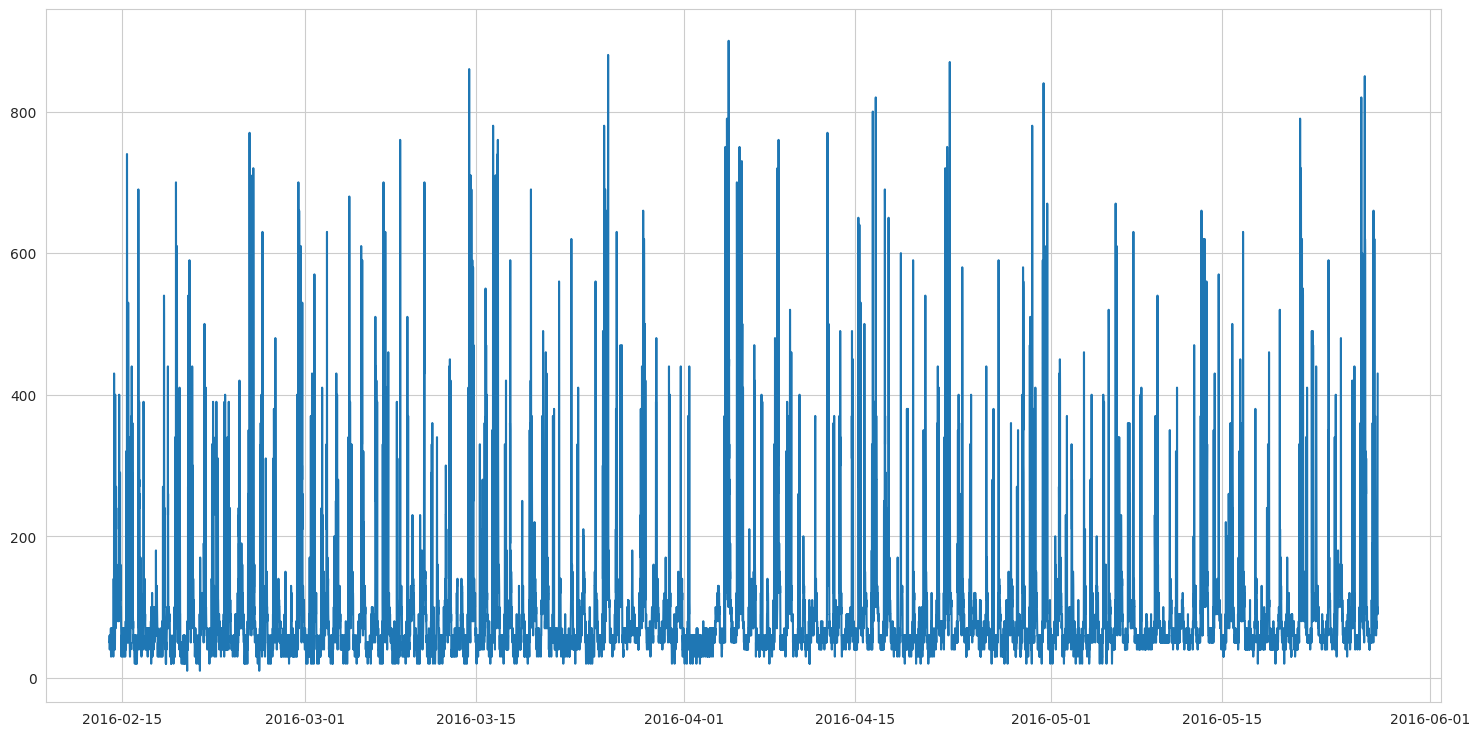

In [19]:
plt.figure(figsize=(18,9))
plt.plot(df.index, df["Appliances"], linestyle="-")
plt.xlabel=('Time')
plt.ylabel=('Appliances')
plt.show();

Looking at the plot we can observe there is an upward trend over the period of time. In addition to this, there is a seasonality in this data. So we will use SARIMA(Seasonal ARIMA) instead of ARIMA.

Seasonal ARIMA, is an extension of ARIMA that explicitly supports univariate time series data with a seasonal component. It adds three new hyperparameters to specify the autoregression (AR), differencing (I) and moving average (MA) for the seasonal component of the series, as well as an additional parameter for the period of the seasonality.

# Decomposition

In [21]:
# Set the frequency of the datetime index
df = df.asfreq('10T') # 10 minutes frequency

rcParams['figure.figsize'] = 12, 8
a = seasonal_decompose(df["Appliances"], model="add")
a.plot()

/tmp/ipykernel_39372/2173282336.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.asfreq('10T') # 10 minutes frequency


ValueError: freq MIN not understood. Please report if you think this is in error.

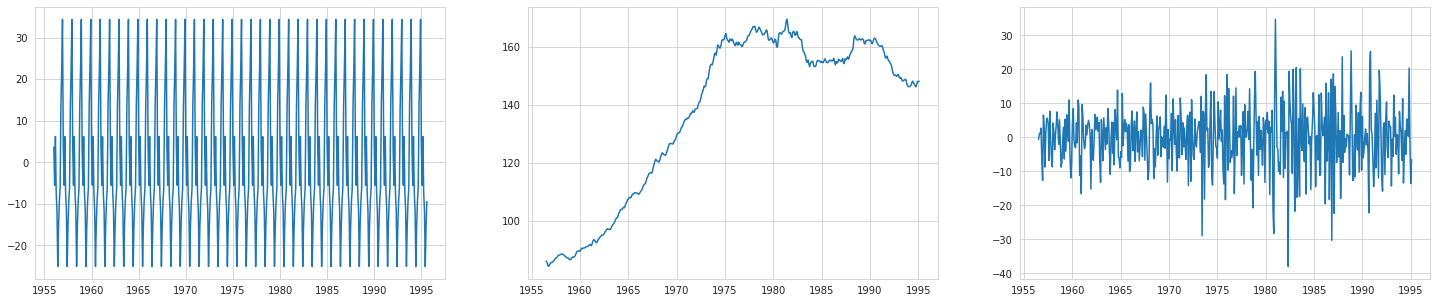

In [8]:
plt.figure(figsize = (25,5))
a = seasonal_decompose(df["Monthly beer production"], model = "add")
plt.subplot(1, 3, 1)
plt.plot(a.seasonal)

plt.subplot(1, 3, 2)
plt.plot(a.trend)

plt.subplot(1, 3, 3)
plt.plot(a.resid)

plt.show()


# Forecasting Models

**ARIMA Model** stands for Auto-Regressive Integrated Moving Average. It is is used for predicting future trends on a time series data. It is model that form of regression analysis.

**Auto-Regressive** models predict future behavior using past behavior where there is some correlation between past and future data.

**Integration** is the difference between present and previous observations. It is used to make the time series stationary.

**Moving Average** is a statistical method that takes the updated average of values to help cut down on noise. It takes the average over a specific interval of time

In [22]:
train_size = int(len(df) * 0.75)
train_data = df[:train_size]
test_data = df[train_size:]

In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


# Define ARIMA Model

In [24]:
arima_model = SARIMAX(train_data['Appliances'], order = (2,1,1), seasonal_order = (4,0,3,12))
arima_result = arima_model.fit()
arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                         SARIMAX Results                                          
==================================================================================================
Dep. Variable:                                 Appliances   No. Observations:                11205
Model:             SARIMAX(2, 1, 1)x(4, 0, [1, 2, 3], 12)   Log Likelihood              -62877.377
Date:                                    Mon, 10 Mar 2025   AIC                         125776.753
Time:                                            17:16:46   BIC                         125857.318
Sample:                                        02-14-2016   HQIC                        125803.870
                                             - 05-01-2016                                         
Covariance Type:                                      opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6537      0.007     96.988      0.000       0.640       0.667
ar.L2         -0.1655      0.006    -29.476      0.000      -0.176      -0.154
ma.L1         -0.8805      0.005   -176.389      0.000      -0.890      -0.871
ar.S.L12       0.0062      4.247      0.001      0.999      -8.318       8.330
ar.S.L24      -0.0008      3.814     -0.000      1.000      -7.476       7.474
ar.S.L36      -0.0719      1.775     -0.040      0.968      -3.551       3.407
ar.S.L48      -0.0038      0.067     -0.056      0.955      -0.136       0.128
ma.S.L12       0.0004      4.247   9.02e-05      1.000      -8.324       8.324
ma.S.L24      -0.0159      3.800     -0.004      0.997      -7.463       7.431
ma.S.L36       0.0628      1.735      0.036      0.971      -3.339       3.464
sigma2      4385.5333     17.469    251.044      0.000    4351.294    4419.772
===================================================================================
Ljung-Box (L1) (Q):                   0.71   Jarque-Bera (JB):            239531.73
Prob(Q):                              0.40   Prob(JB):                         0.00
Heteroskedasticity (H):               0.93   Skew:                             3.07
Prob(H) (two-sided):                  0.03   Kurtosis:                        24.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# Predictions

In [25]:
arima_pred = arima_result.predict(start = len(train_data), end = len(df)-1, typ="levels").rename("ARIMA Predictions")
arima_pred

/home/james/MyFolder/code/GIT/mbd/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


2016-05-01 19:30:00    143.999771
2016-05-01 19:40:00    177.551308
2016-05-01 19:50:00    192.073235
2016-05-01 20:00:00    195.383805
2016-05-01 20:10:00    192.564645
                          ...    
2016-05-27 17:20:00    190.004121
2016-05-27 17:30:00    190.004121
2016-05-27 17:40:00    190.004121
2016-05-27 17:50:00    190.004121
2016-05-27 18:00:00    190.004121
Freq: 10min, Name: ARIMA Predictions, Length: 3736, dtype: float64

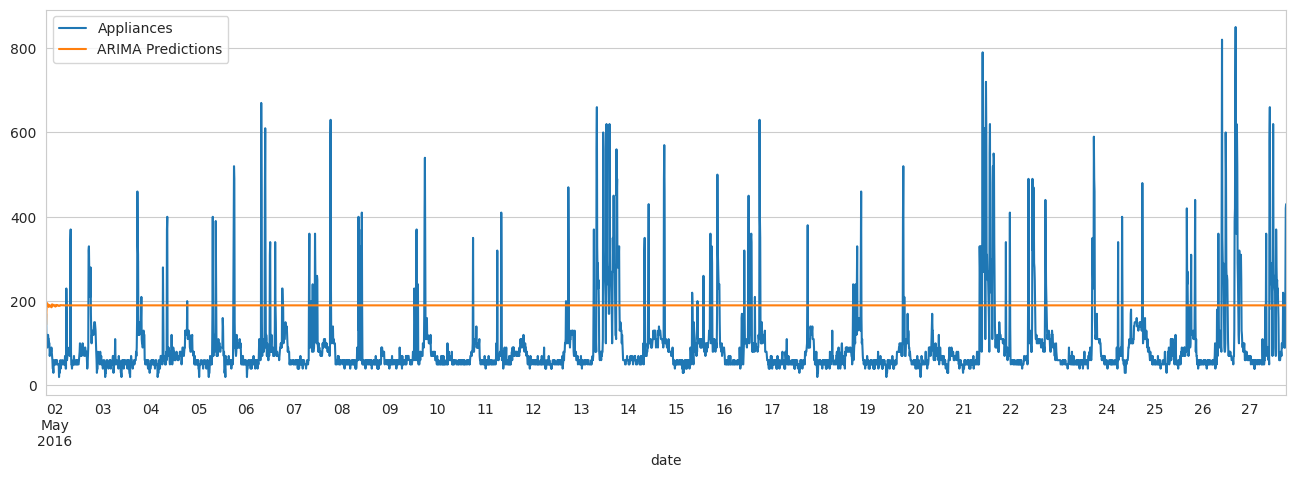

In [26]:
test_data['Appliances'].plot(figsize = (16,5), legend=True)
arima_pred.plot(legend = True);

In [27]:
from statsmodels.tools.eval_measures import rmse

# RMSE/MSE Errors

In [29]:
arima_rmse_error = rmse(test_data['Appliances'], arima_pred)
arima_mse_error = arima_rmse_error**2
mean_value = df['Appliances'].mean()

print(f'MSE Error: {arima_mse_error}\nRMSE Error: {arima_rmse_error}\nMean: {mean_value}')

MSE Error: 16733.818878617414
RMSE Error: 129.3592628249613
Mean: 96.74720567565758


The statsmodels library provides the capability to fit an ARIMA model.

An ARIMA model can be created using the statsmodels library as follows:

1. Define the model by calling ARIMA() and passing in the p, d, and q parameters.
2. The model is prepared on the training data by calling the fit() function.
3. Predictions can be made by calling the predict() function and specifying the index of the time or times to be predicted.

Let’s start off with something simple. We will fit an ARIMA model to the entire Monthly Beer Production dataset.


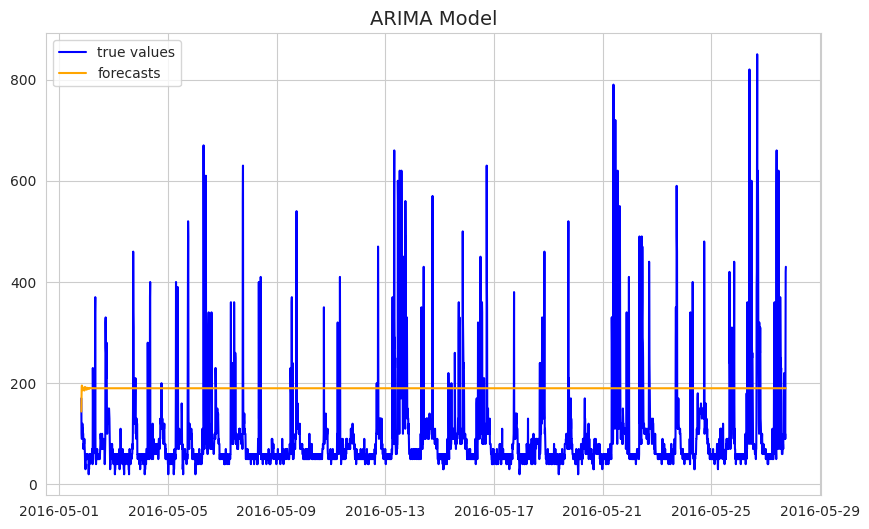

In [30]:
plt.figure(figsize = (10,6))
plt.plot(test_data, label = "true values", color = "blue")
plt.plot(arima_pred,label = "forecasts", color='orange')
plt.title("ARIMA Model", size = 14)
plt.legend(loc = 'upper left')
plt.show()

In [17]:
test_data['ARIMA_Predictions'] = arima_pred


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [18]:
test_data

,Monthly beer production,ARIMA_Predictions
Month,,
1994-09-01,143.0,134.005356
1994-10-01,160.0,157.579894
1994-11-01,190.0,182.136381
1994-12-01,182.0,183.627387
1995-01-01,138.0,144.730490
1995-02-01,136.0,137.017380
1995-03-01,152.0,151.196686
1995-04-01,127.0,133.181514
1995-05-01,151.0,138.287092


# References

https://www.kaggle.com/code/sercanyesiloz/electricity-production-forecasting-arima/notebook#Mean%20Squared%20Errors

https://www.miuul.com/zaman-serileri

Thank you for your suggestions and comments :)